# MNIST

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Convert MNIST img files into a tensor of 4-dim
transform = transforms.ToTensor()

# Call and save train/test datasets
train_data = datasets.MNIST(root="../datasets/mnist_data", train=True, download=True, transform=transform)

test_data = datasets.MNIST(root="../datasets/mnist_data", train=False, download=True, transform=transform)

100.0%
100.0%
100.0%
100.0%


In [4]:
# Create a small batch size for imgs (eg. 10)
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=True)

# Define CNN Model

In [5]:
# Describe the convolutional layer, we do 2D here
# nn.Conv2d(in_channels, out_channels, kernel_size, stride)
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [6]:
# Take only 1 MNIST img
for i, (X_train, y_train) in enumerate(train_data):
    break

In [7]:
X_train.shape

torch.Size([1, 28, 28])

In [8]:
x = X_train.view(1, 1, 28, 28)

### A Convolution Layer

In [9]:
# Perform the first convolu
x = F.relu(conv1(x)) # Rectified Linear Unit for the activation function

In [10]:
x.shape     # after a convo

torch.Size([1, 6, 26, 26])

### A Pooling Layer

In [11]:
x = F.max_pool2d(x, 2, 2)   # kernal of 2 and stride of 2
x.shape

torch.Size([1, 6, 13, 13])

### The 2nd Convolutional Layer

In [12]:
x = F.relu(conv2(x))

x.shape

torch.Size([1, 16, 11, 11])

### The 2nd Pooling Layer

In [13]:
x = F.max_pool2d(x, 2, 2)
x.shape

torch.Size([1, 16, 5, 5])

### Create the CNN class

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        # Fully Connected Layer
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, X):
        # First pass
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)   # 2x2 kernel with stride = 2

        # Second pass
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)   # 2x2 kernel with stride = 2

        # review to flatten it out
        X = X.view(-1, 16*5*5)

        # Fully connected layers
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = F.relu(self.fc3(X))

        return F.log_softmax(X, dim=1)

In [16]:
torch.manual_seed(41)
cnn = CNN()
cnn

CNN(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [17]:
# Loss Function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

### Train and Test

In [19]:
import time
start_time = time.time()

# Create Variables to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# For loop of Epochs
for i in range(epochs):
    train_corr = 0
    test_corr = 0
    
    # Train
    for batch, (X_train, y_train) in enumerate(train_loader):
        batch += 1
        y_pred = cnn(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        train_corr += batch_corr

        # Update params
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print result
        if batch%600 == 0:
            print(f"Epoch: {i} Batch {batch} Loss: {loss.item()}")
    
    train_losses.append(loss)
    train_correct.append(train_corr)

    
    # Test
    with torch.no_grad():       # No gradient => no update w and bias on test
        for batch, (X_test, y_test) in enumerate(test_loader):
            y_val = cnn(X_test)
            predicted = torch.max(y_val.data, 1)[1]
            test_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(test_corr)


current_time = time.time()
total = current_time - start_time
print(f"Training total time: {total/60} minutes!")

Epoch: 0 Batch 600 Loss: 1.1820828914642334
Epoch: 0 Batch 1200 Loss: 1.3949077129364014
Epoch: 0 Batch 1800 Loss: 1.6228069067001343
Epoch: 0 Batch 2400 Loss: 1.2031978368759155
Epoch: 0 Batch 3000 Loss: 1.3819615840911865
Epoch: 0 Batch 3600 Loss: 1.392475962638855
Epoch: 0 Batch 4200 Loss: 1.8429124355316162
Epoch: 0 Batch 4800 Loss: 1.1627540588378906
Epoch: 0 Batch 5400 Loss: 1.6121078729629517
Epoch: 0 Batch 6000 Loss: 1.405107855796814
Epoch: 1 Batch 600 Loss: 1.3683754205703735
Epoch: 1 Batch 1200 Loss: 1.3817189931869507
Epoch: 1 Batch 1800 Loss: 1.38473379611969
Epoch: 1 Batch 2400 Loss: 0.9211233258247375
Epoch: 1 Batch 3000 Loss: 0.6919366121292114
Epoch: 1 Batch 3600 Loss: 1.6581459045410156
Epoch: 1 Batch 4200 Loss: 1.842564344406128
Epoch: 1 Batch 4800 Loss: 1.1547582149505615
Epoch: 1 Batch 5400 Loss: 1.3834865093231201
Epoch: 1 Batch 6000 Loss: 1.5204267501831055
Epoch: 2 Batch 600 Loss: 2.1174731254577637
Epoch: 2 Batch 1200 Loss: 1.1542119979858398
Epoch: 2 Batch 180

### Graph the result

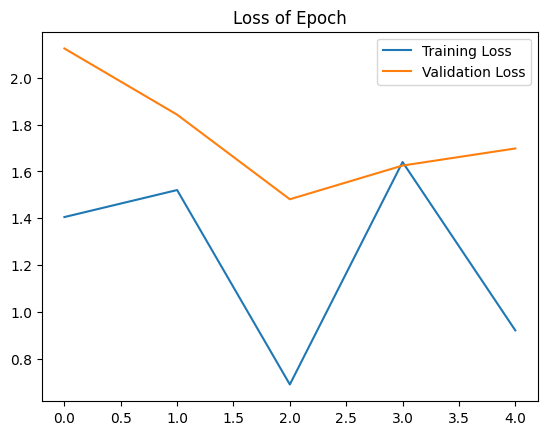

In [20]:
train_losses = [tl.item() for tl in train_losses]

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Validation Loss")
plt.title("Loss of Epoch")
plt.legend()

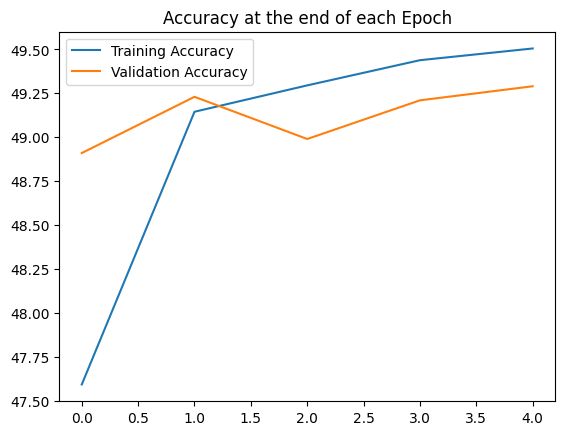

In [22]:
# Graph accuracy at the end of each epoch
plt.plot([t/600 for t in train_correct], label="Training Accuracy")
plt.plot([t/100 for t in test_correct], label="Validation Accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend()
